# 5 · Motion, learning and nowcasting

Motion estimated by LK, VET, DARTS and Proesmans and by a network trained on the simulator's
true flow, scored against the true motion (regional study) and, on real radar where no true
motion exists, by the nowcast each motion field makes. Then the nowcasts of the regional study.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from core import viz_style as vs
%matplotlib inline
vs.use_style()
pd.set_option("display.width", 160)
FIG = Path("../results/figures")
TAB = Path("../results/tables")

import json

## Motion against the true flow (regional study)

Median endpoint error where it rains (km/h), from the last four 5-min fields:

In [2]:
mo = pd.read_csv(TAB / "regional/motion.csv")
w = mo[mo.region == "wet"]
w.pivot_table(index="product", columns="method", values="epe_kmh", aggfunc="median").round(1)

method,DARTS,LK,VET,learned,learned+LK,proesmans
product,,,,,,
idw links,28.6,23.3,67.2,31.9,23.5,44.3
ked [links+gauges],20.8,5.2,5.1,8.0,4.7,17.6
radar,14.9,4.3,3.1,7.1,3.5,10.9
truth,14.7,4.2,2.4,6.5,3.2,9.3


In [3]:
w[w["product"] == "radar"].pivot_table(index="method", columns="flow", values="epe_kmh", aggfunc="median").round(1)

flow,random,rotation,shear,uniform
method,,,,
DARTS,28.1,30.1,14.9,13.1
LK,6.3,12.7,9.9,1.4
VET,4.6,4.7,6.6,2.3
learned,7.7,12.2,9.5,4.2
learned+LK,5.4,6.8,7.1,1.3
proesmans,15.5,8.6,14.0,10.6


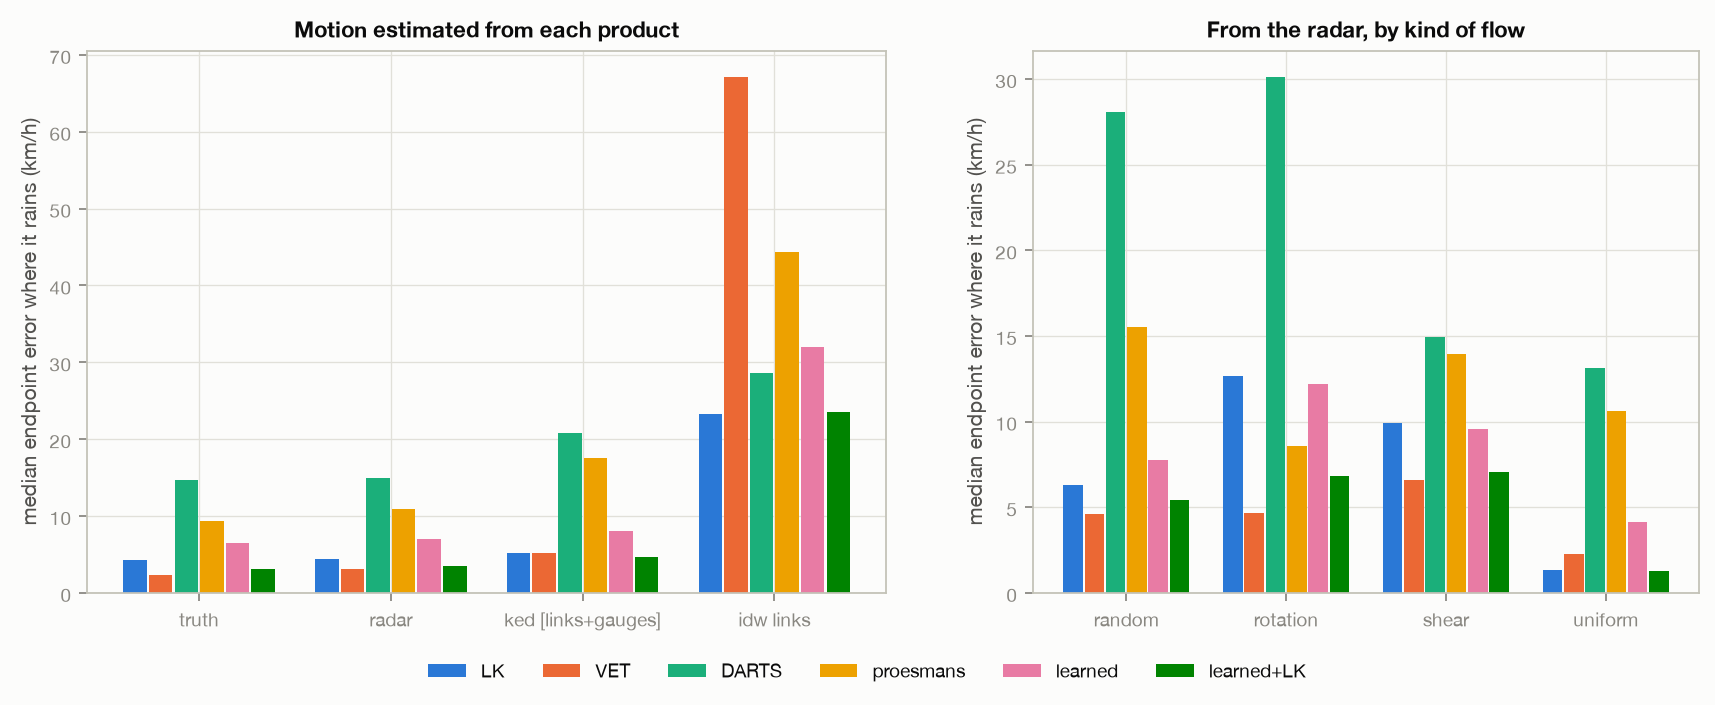

In [4]:
display(Image(str(FIG / "fig06_motion.png")))

## The learned estimators

Both are U-Nets trained on 700 simulated sequences (2,796 samples) with their true flow:
`learned` from the fields alone, `learned+LK` as a correction to Lucas-Kanade.
Validation error (px per step):

In [5]:
{p.stem: round(json.load(open(p))["val_epe_px"], 2) for p in sorted(Path("../results/models").glob("*.json"))}

{'learned_motion': 1.32, 'learned_motion_LK': 0.7}

In [6]:
q = w[w["product"] == "radar"].pivot_table(index=["scenario", "issue"], columns="method", values="epe_kmh")
pd.DataFrame({f"{a} vs {b}": {"better in": f"{((q[a] - q[b]) < 0).mean():.0%}", "median difference (km/h)": round((q[a] - q[b]).median(), 2)}
              for a, b in [("learned+LK", "LK"), ("learned+LK", "VET"), ("learned", "VET")]}).T

,better in,median difference (km/h)
learned+LK vs LK,62%,-0.15
learned+LK vs VET,49%,0.08
learned vs VET,10%,3.05


## On real radar

OpenMRG (SMHI, 5 min, 2 km) and OpenRainER (ARPAE, 15 min, 2 km), the events of
`os_nowcasting`. No true motion here: each motion field is scored by the extrapolation it makes,
against the radar that followed.

**openmrg**, 262 issue times - CSI at 1 mm/h

lead_min,10,20,30,40,50,60
method,,,,,,
DARTS,0.511,0.406,0.349,0.312,0.281,0.247
LK,0.630,0.542,0.475,0.421,0.369,0.326
VET,0.601,0.506,0.439,0.392,0.342,0.301
learned,0.605,0.517,0.449,0.397,0.350,0.303
learned+LK,0.630,0.542,0.474,0.421,0.368,0.324
persistence,0.452,0.345,0.296,0.259,0.229,0.197
proesmans,0.618,0.529,0.455,0.403,0.353,0.314


**openrainer**, 147 issue times - CSI at 1 mm/h

lead_min,30,60
method,,
LK,0.561,0.383
VET,0.569,0.388
learned,0.536,0.353
learned+LK,0.561,0.382
persistence,0.412,0.257
proesmans,0.564,0.390


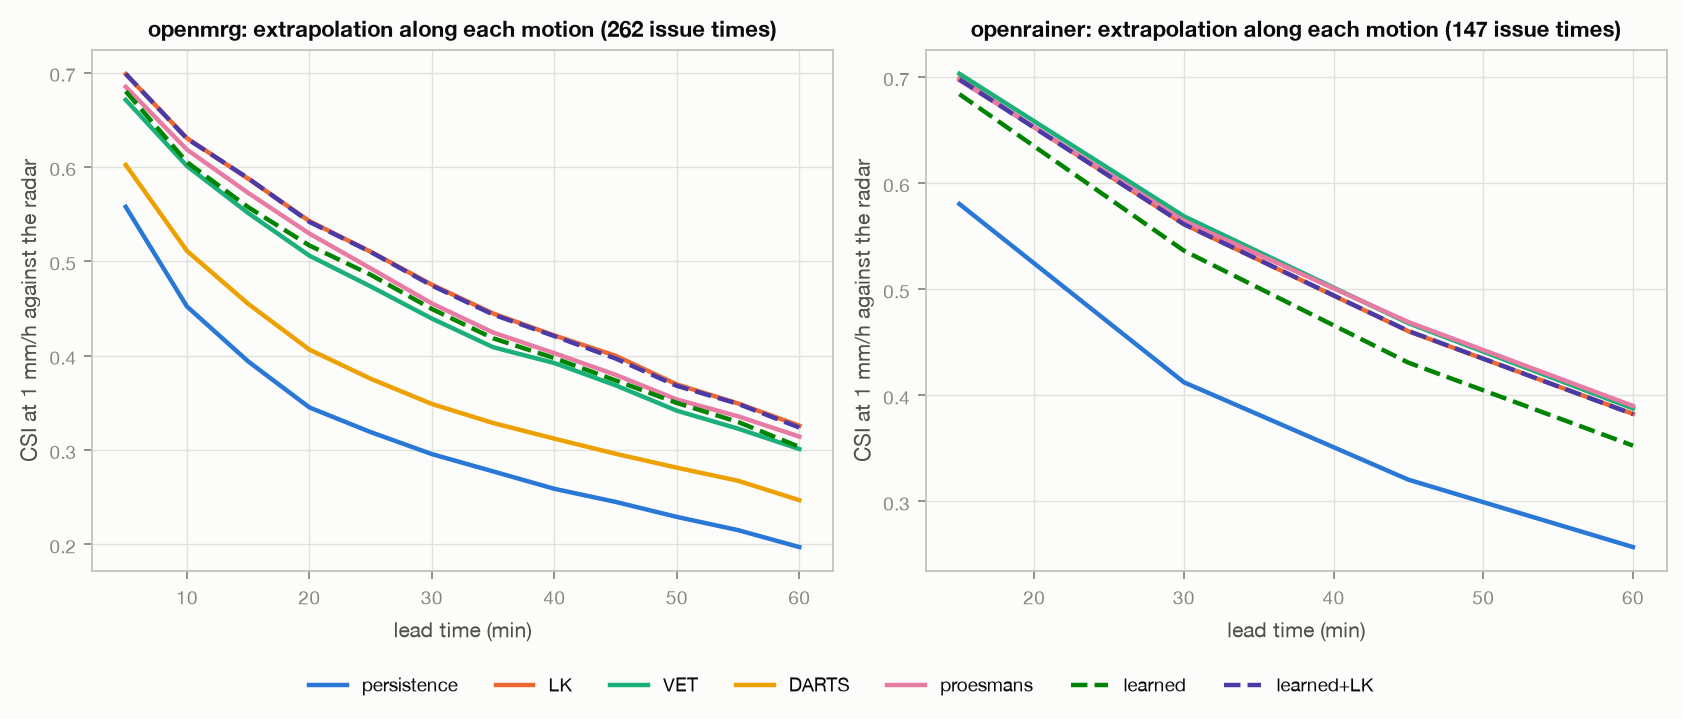

In [7]:
real = {n: pd.read_csv(TAB / f"real_radar_{n}.csv") for n in ("openmrg", "openrainer") if (TAB / f"real_radar_{n}.csv").exists()}
for n, r in real.items():
    display(Markdown(f"**{n}**, {int(r.n_issues.iloc[0])} issue times - CSI at 1 mm/h"))
    display(r.pivot_table(index="method", columns="lead_min", values="CSI_1").round(3).iloc[:, 1::2])
display(Image(str(FIG / "fig10_real_radar.png")))

## Nowcasts against the truth (regional study)

In [8]:
now = pd.read_csv(TAB / "regional/nowcast.csv")
now[now.lead_min.isin([30, 60])].pivot_table(index=["product", "method"], columns="lead_min", values="CSI_1").round(2)

lead_min                                        30.0  60.0
product            method                                 
ked [links+gauges] extrapolation                0.54  0.44
                   extrapolation (learned)      0.51  0.40
                   extrapolation (learned+LK)   0.54  0.45
                   extrapolation (true motion)  0.58  0.50
                   persistence                  0.40  0.32
                   sprog                        0.54  0.44
                   steps (mean)                 0.50  0.41
radar              extrapolation                0.53  0.42
                   extrapolation (learned)      0.50  0.37
                   extrapolation (learned+LK)   0.54  0.43
                   extrapolation (true motion)  0.58  0.49
                   persistence                  0.36  0.27
                   sprog                        0.53  0.43
                   steps (mean)                 0.51  0.40
truth              extrapolation                0.56  0.44
                   extrapolation (learned)      0.53  0.40
                   extrapolation (learned+LK)   0.57  0.46
                   extrapolation (true motion)  0.61  0.50
                   persistence                  0.36  0.28
                   sprog                        0.56  0.44
                   steps (mean)                 0.54  0.43

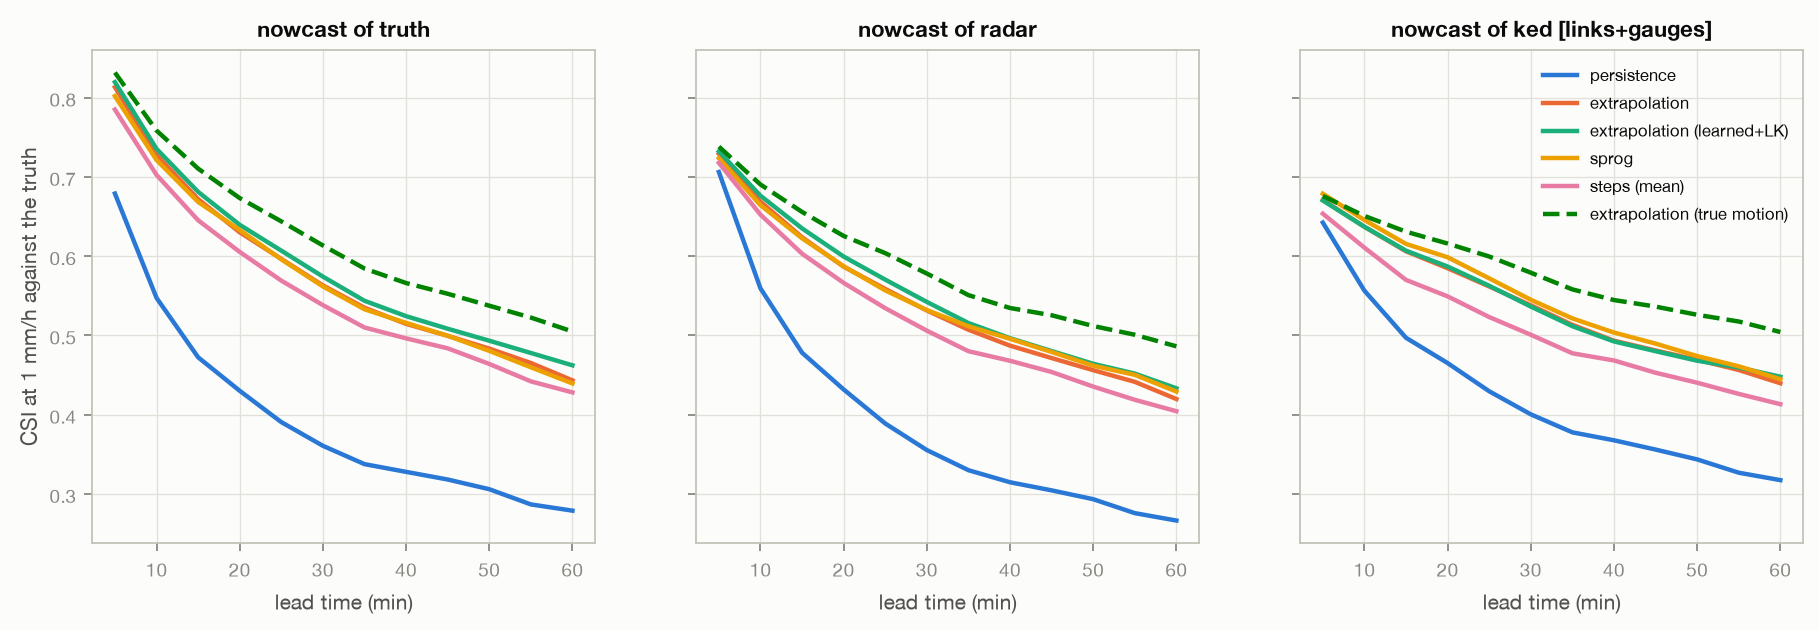

In [9]:
display(Image(str(FIG / "fig07_nowcast.png")))

## Convective rain with a life cycle

`run.py regional --set lifecycle`: twelve scenarios of cells only, every one born, growing and
decaying.

In [10]:
lc = TAB / "regional_lifecycle"
if (lc / "nowcast.csv").exists():
    nl = pd.read_csv(lc / "nowcast.csv")
    display(nl[nl.lead_min.isin([30, 60])].pivot_table(index=["product", "method"], columns="lead_min", values="CSI_1").round(2))
    ml = pd.read_csv(lc / "motion.csv")
    display(ml[ml.region == "wet"].pivot_table(index="product", columns="method", values="epe_kmh", aggfunc="median").round(1))

lead_min                                        30.0  60.0
product            method                                 
ked [links+gauges] extrapolation                0.39  0.25
                   extrapolation (learned)      0.35  0.21
                   extrapolation (learned+LK)   0.39  0.26
                   extrapolation (true motion)  0.45  0.37
                   persistence                  0.18  0.15
                   sprog                        0.40  0.26
                   steps (mean)                 0.35  0.22
radar              extrapolation                0.40  0.26
                   extrapolation (learned)      0.39  0.26
                   extrapolation (learned+LK)   0.41  0.26
                   extrapolation (true motion)  0.48  0.38
                   persistence                  0.18  0.12
                   sprog                        0.42  0.27
                   steps (mean)                 0.38  0.24
truth              extrapolation                0.41  0.27
                   extrapolation (learned)      0.40  0.26
                   extrapolation (learned+LK)   0.42  0.28
                   extrapolation (true motion)  0.50  0.39
                   persistence                  0.17  0.12
                   sprog                        0.43  0.27
                   steps (mean)                 0.39  0.25

method,DARTS,LK,VET,learned,learned+LK,proesmans
product,,,,,,
idw links,31.4,20.7,41.0,28.2,19.8,44.7
ked [links+gauges],14.5,4.8,6.3,8.4,5.1,11.3
radar,12.5,4.0,5.5,7.2,4.4,7.4
truth,12.1,3.9,5.0,6.4,4.7,7.0
